In [ ]:
import pandas as pd

df = pd.read_csv(r"D:\Project_Beta\Raw_Data.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df=df.rename(columns={'age':"Age",
                   'sex':'Sex',
                   "bmi":"BMI",
                   "children":"No_of_Children",
                   "smoker":"Smoker",
                   "region":"Region",
                   "charges":"Charges"})
df.head()

,Age,Sex,BMI,No_of_Children,Smoker,Region,Charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df = df.map(lambda x: str(x).strip())
df.isnull().sum()

Age               0
Sex               0
BMI               0
No_of_Children    0
Smoker            0
Region            0
Charges           0
dtype: int64

In [10]:
convert_dict = {'Age': int, 'BMI': float,'No_of_Children':int,'Charges':float}

df=df.astype(convert_dict)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1338 non-null   int64  
 1   Sex             1338 non-null   str    
 2   BMI             1338 non-null   float64
 3   No_of_Children  1338 non-null   int64  
 4   Smoker          1338 non-null   str    
 5   Region          1338 non-null   str    
 6   Charges         1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [13]:
bins = [0,16,30,45,100]
labels = ['Child','Young_Adults','Middle_Aged_Adults','Old_Aged_Adults']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

bmi_bins = [0, 18.5, 24.9, 29.9, 100]
bmi_labels = ['Underweight', 'Healthy', 'Overweight', 'Obese']

# 2. Categorize the BMI column in your DataFrame
df['BMI_Range'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels)

df.head()

,Age,Sex,BMI,No_of_Children,Smoker,Region,Charges,Age_Group,BMI_Range
0,19,female,27.900,0,yes,southwest,16884.92400,Young_Adults,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Young_Adults,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Young_Adults,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Middle_Aged_Adults,Healthy
4,32,male,28.880,0,no,northwest,3866.85520,Middle_Aged_Adults,Overweight


In [14]:
df['Region'] = df['Region'].str.replace(r'(south|north)(west|east)', r'\1 \2', case=False, regex=True)

In [15]:
df.describe()

,Age,BMI,No_of_Children,Charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [18]:
df.sort_values(by = 'Charges').head(20)

,Age,Sex,BMI,No_of_Children,Smoker,Region,Charges,Age_Group,BMI_Range
940,18,male,23.21,0,no,south east,1121.8739,Young_Adults,Healthy
808,18,male,30.14,0,no,south east,1131.5066,Young_Adults,Obese
1244,18,male,33.33,0,no,south east,1135.9407,Young_Adults,Obese
663,18,male,33.66,0,no,south east,1136.3994,Young_Adults,Obese
22,18,male,34.10,0,no,south east,1137.0110,Young_Adults,Obese
194,18,male,34.43,0,no,south east,1137.4697,Young_Adults,Obese
866,18,male,37.29,0,no,south east,1141.4451,Young_Adults,Obese
781,18,male,41.14,0,no,south east,1146.7966,Young_Adults,Obese
442,18,male,43.01,0,no,south east,1149.3959,Young_Adults,Obese
1317,18,male,53.13,0,no,south east,1163.4627,Young_Adults,Obese


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
df.corr(numeric_only=True)

,Age,BMI,No_of_Children,Charges
Age,1.000000,0.109272,0.042469,0.299008
BMI,0.109272,1.000000,0.012759,0.198341
No_of_Children,0.042469,0.012759,1.000000,0.067998
Charges,0.299008,0.198341,0.067998,1.000000


In [26]:
# Compare average charges and BMI across different age categories
age_analysis = df.groupby('Age_Group', observed=False)[['Charges', 'BMI']].agg(['mean', 'median', 'count'])
print(age_analysis)

                         Charges                            BMI              
                            mean        median count       mean  median count
Age_Group                                                                    
Child                        NaN           NaN     0        NaN     NaN     0
Young_Adults         9397.552051   3392.671000   444  29.890766  29.815   444
Middle_Aged_Adults  12647.455654   7146.167725   394  30.442170  29.920   394
Old_Aged_Adults     17200.428704  12136.096375   500  31.523820  31.500   500


C:\Users\ACER\AppData\Local\Temp\ipykernel_5724\3439724617.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Age_Group', y='Charges', estimator='mean', errorbar=None, palette='muted')


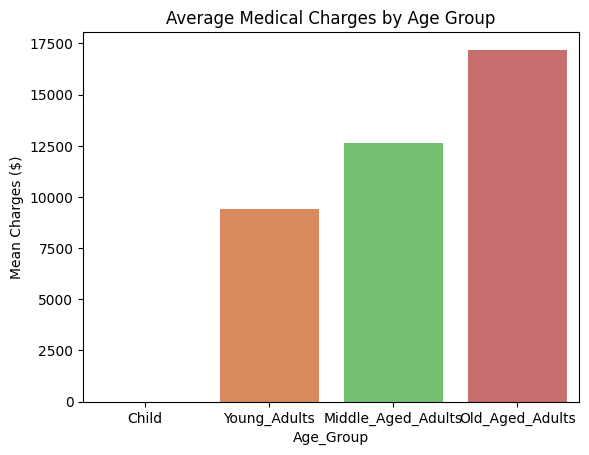

In [27]:


sns.barplot(data=df, x='Age_Group', y='Charges', estimator='mean', errorbar=None, palette='muted')
plt.title('Average Medical Charges by Age Group')
plt.ylabel('Mean Charges ($)')
plt.show()

In [28]:
df[['Charges', 'BMI']].describe()

,Charges,BMI
count,1338.000000,1338.000000
mean,13270.422265,30.663397
std,12110.011237,6.098187
min,1121.873900,15.960000
25%,4740.287150,26.296250
50%,9382.033000,30.400000
75%,16639.912515,34.693750
max,63770.428010,53.130000


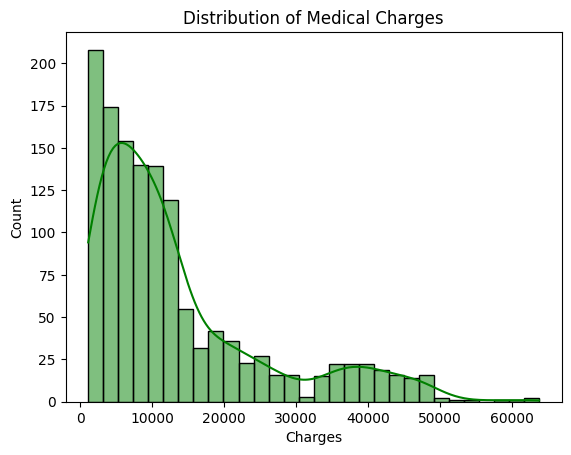

In [30]:
# Look at the spread of Charges to spot high-cost outliers
sns.histplot(data=df, x='Charges', kde=True, color='green')
plt.title('Distribution of Medical Charges')
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_5724\232009586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='No_of_Children', y='BMI', palette='pastel')


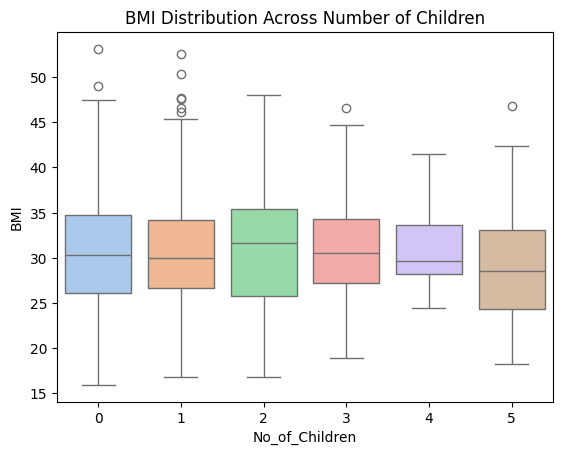

In [31]:
# See if BMI spreads differently depending on the number of children
sns.boxplot(data=df, x='No_of_Children', y='BMI', palette='pastel')
plt.title('BMI Distribution Across Number of Children')
# Focuses the view on standard ranges
plt.show()

In [32]:
# Calculate the exact count of patient segments across regions
region_bmi_counts = pd.crosstab(df['Region'], df['BMI_Range'])
print(region_bmi_counts)

BMI_Range   Underweight  Healthy  Overweight  Obese
Region                                             
north east           10       72          98    144
north west            7       62         106    150
south east            0       40          75    249
south west            4       47         101    173


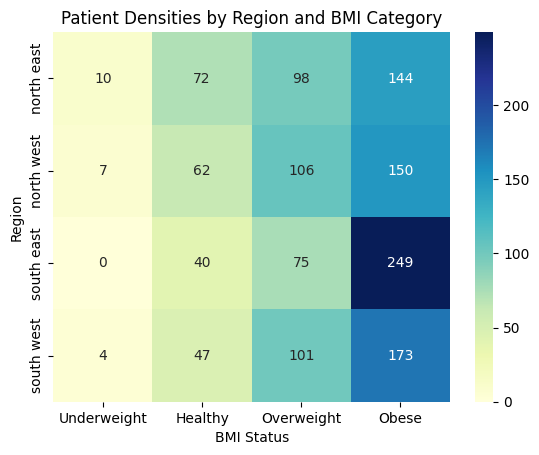

In [33]:
sns.heatmap(region_bmi_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Patient Densities by Region and BMI Category')
plt.ylabel('Region')
plt.xlabel('BMI Status')
plt.show()

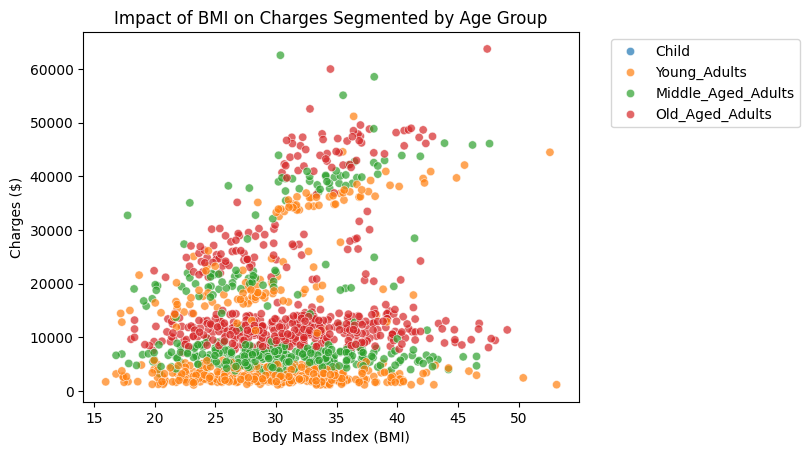

In [34]:
# Plot BMI vs Charges, but color-code the dots by Age Group
sns.scatterplot(data=df, x='BMI', y='Charges', hue='Age_Group', alpha=0.7)
plt.title('Impact of BMI on Charges Segmented by Age Group')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Charges ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside chart
plt.show()

Age	Sex	BMI	No_of_Children	Smoker	Region	Charges

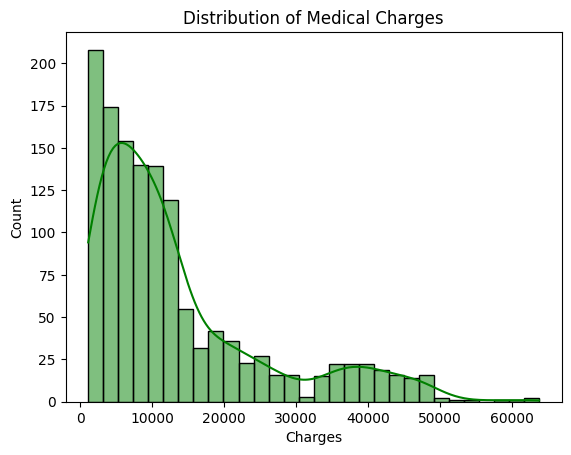

In [46]:
sns.histplot(data=df, x='Charges', kde=True, color='green')
plt.title('Distribution of Medical Charges')
plt.show()

In [40]:
df

,Age,Sex,BMI,No_of_Children,Smoker,Region,Charges,Age_Group,BMI_Range
0,19,female,27.900,0,yes,south west,16884.92400,Young_Adults,Overweight
1,18,male,33.770,1,no,south east,1725.55230,Young_Adults,Obese
2,28,male,33.000,3,no,south east,4449.46200,Young_Adults,Obese
3,33,male,22.705,0,no,north west,21984.47061,Middle_Aged_Adults,Healthy
4,32,male,28.880,0,no,north west,3866.85520,Middle_Aged_Adults,Overweight
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,north west,10600.54830,Old_Aged_Adults,Obese
1334,18,female,31.920,0,no,north east,2205.98080,Young_Adults,Obese
1335,18,female,36.850,0,no,south east,1629.83350,Young_Adults,Obese
1336,21,female,25.800,0,no,south west,2007.94500,Young_Adults,Overweight


In [44]:
region_smoker_counts = pd.crosstab(df['Charges'], df['Smoker'])
print(region_smoker_counts)

Smoker       no  yes
Charges             
1121.87390    1    0
1131.50660    1    0
1135.94070    1    0
1136.39940    1    0
1137.01100    1    0
...          ..  ...
55135.40209   0    1
58571.07448   0    1
60021.39897   0    1
62592.87309   0    1
63770.42801   0    1

[1337 rows x 2 columns]


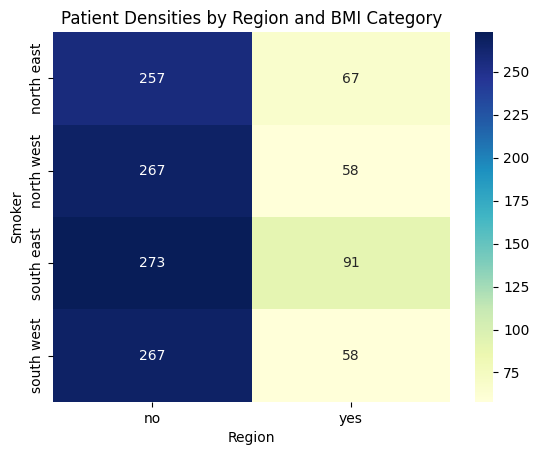

In [43]:
sns.heatmap(region_smoker_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Patient Densities by Region and BMI Category')
plt.ylabel('Smoker')
plt.xlabel('Region')
plt.show()

Age	Sex	BMI	No_of_Children	Smoker	Region	Charges	Age_Group	BMI_Range


In [45]:
BMI_analysis = df.groupby('BMI_Range', observed=False)[['Charges', 'No_of_Children']].agg(['mean', 'median', 'count'])
print(BMI_analysis)

                  Charges                    No_of_Children             
                     mean       median count           mean median count
BMI_Range                                                               
Underweight   8657.620652  6640.544850    21       1.047619    1.0    21
Healthy      10404.900084  8604.483650   221       1.117647    1.0   221
Overweight   11006.809989  8659.378000   380       1.068421    1.0   380
Obese        15491.542238  9895.213925   716       1.103352    1.0   716


C:\Users\ACER\AppData\Local\Temp\ipykernel_5724\2030089596.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='BMI_Range', y='Charges', estimator='mean', errorbar=None, palette='muted')


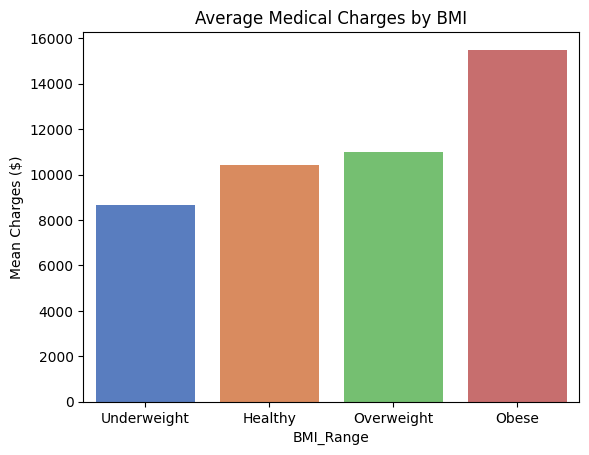

In [49]:
sns.barplot(data=df, x='BMI_Range', y='Charges', estimator='mean', errorbar=None, palette='muted')
plt.title('Average Medical Charges by BMI')
plt.ylabel('Mean Charges ($)')
plt.show()

In [50]:
# Calculate the mean and median charges for smokers vs non-smokers
smoker_impact = df.groupby(['Age_Group', 'Smoker'], observed=False)['Charges'].agg(['mean', 'median', 'count'])
print(smoker_impact)

                                   mean        median  count
Age_Group          Smoker                                   
Child              no               NaN           NaN      0
                   yes              NaN           NaN      0
Young_Adults       no       4462.308505   2755.020950    349
                   yes     27528.078343  33475.817150     95
Middle_Aged_Adults no       7246.170138   6474.013000    307
                   yes     31707.164316  37079.372000     87
Old_Aged_Adults    no      12725.837177  11445.379825    408
                   yes     37044.269389  41797.589050     92


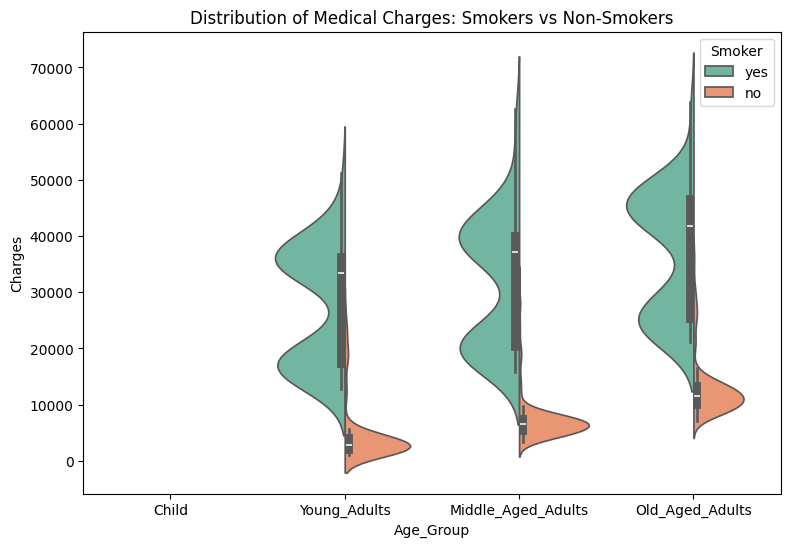

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
sns.violinplot(data=df, x='Age_Group', y='Charges', hue='Smoker', split=True, palette='Set2')
plt.title('Distribution of Medical Charges: Smokers vs Non-Smokers')
plt.show()

In [52]:
# Create a pivot table showing average charges across BMI categories and Smoking habits
risk_matrix = df.pivot_table(index='BMI_Range', columns='Smoker', values='Charges', aggfunc='mean', observed=False)
print(risk_matrix)

Smoker                no           yes
BMI_Range                             
Underweight  5485.056800  18809.824980
Healthy      7616.208985  19942.223641
Overweight   8348.367998  22379.034063
Obese        8809.545659  41355.869131


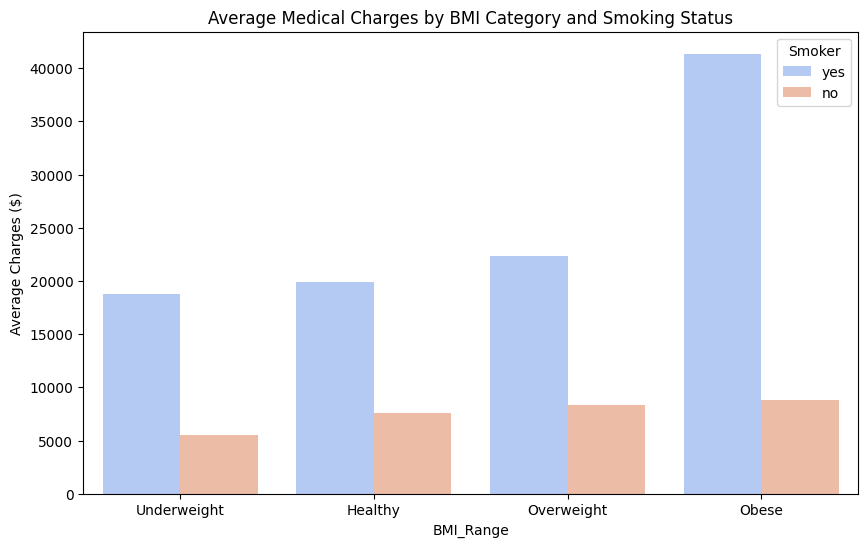

In [53]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='BMI_Range', y='Charges', hue='Smoker', palette='coolwarm', errorbar=None)
plt.title('Average Medical Charges by BMI Category and Smoking Status')
plt.ylabel('Average Charges ($)')
plt.show()

In [54]:
# Compare regional metrics: total financial impact vs patient volume
region_analysis = df.groupby('Region').agg(
    Total_Spending=('Charges', 'sum'),
    Average_Cost=('Charges', 'mean'),
    Patient_Count=('Charges', 'count'),
    Smoker_Rate=('Smoker', lambda x: (x == 'yes').mean() * 100) # Percentage of smokers
)
print(region_analysis)

            Total_Spending  Average_Cost  Patient_Count  Smoker_Rate
Region                                                              
north east    4.343669e+06  13406.384516            324    20.679012
north west    4.035712e+06  12417.575374            325    17.846154
south east    5.363690e+06  14735.411438            364    25.000000
south west    4.012755e+06  12346.937377            325    17.846154


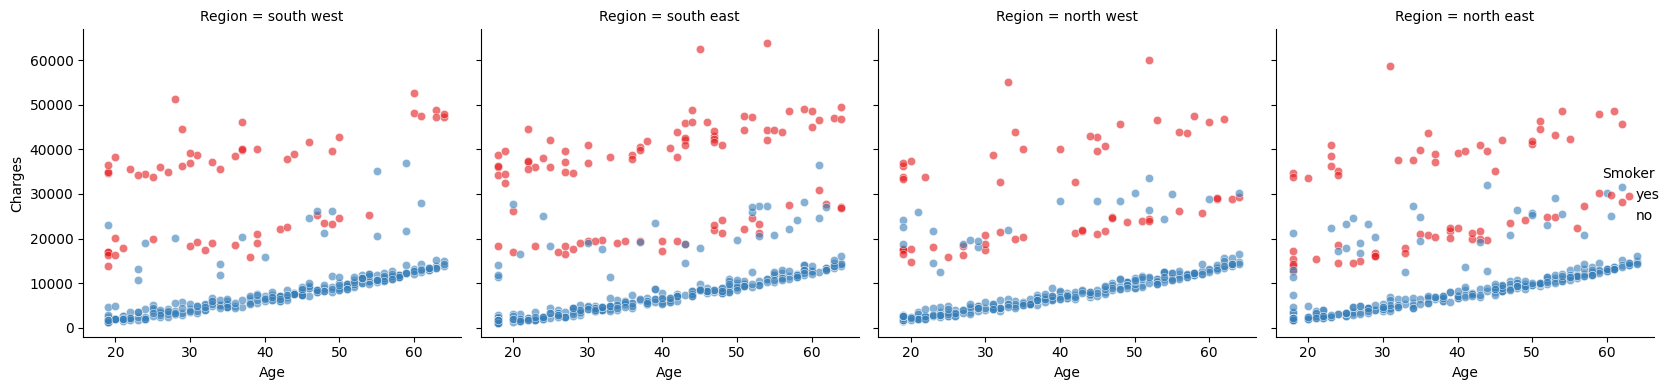

In [57]:
# Creates a separate scatter plot for each region automatically
g = sns.FacetGrid(df, col="Region", hue="Smoker", palette="Set1", height=4, aspect=1)
g.map(sns.scatterplot, "Age", "Charges", alpha=0.6)
g.add_legend()
plt.tight_layout()
plt.show()

In [58]:
# Look at average charges and average age based on family size
dependent_analysis = df.groupby('No_of_Children')[['Charges', 'Age']].mean()
print(dependent_analysis)

                     Charges        Age
No_of_Children                         
0               12365.975602  38.444251
1               12731.171832  39.453704
2               15073.563734  39.445833
3               15355.318367  41.566879
4               13850.656311  39.000000
5                8786.035247  35.611111


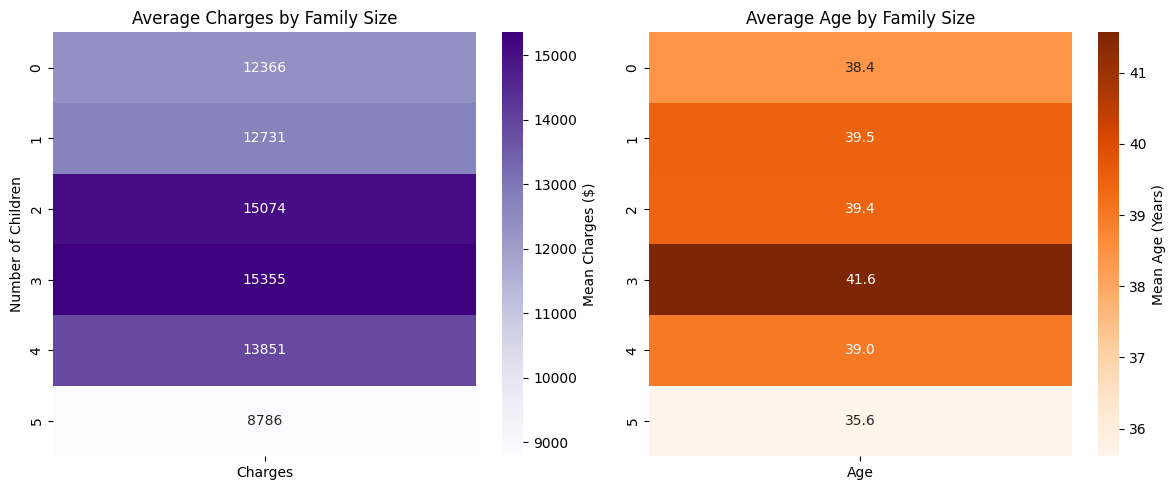

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Run your aggregation code
dependent_analysis = df.groupby('No_of_Children')[['Charges', 'Age']].mean()

# 2. Set up a plotting area with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot A: Average Charges Heatmap (Left Side)
sns.heatmap(
    dependent_analysis[['Charges']], 
    annot=True, 
    fmt=".0f", 
    cmap="Purples", 
    ax=axes[0],
    cbar_kws={'label': 'Mean Charges ($)'}
)
axes[0].set_title('Average Charges by Family Size')
axes[0].set_ylabel('Number of Children')

# Plot B: Average Age Heatmap (Right Side)
sns.heatmap(
    dependent_analysis[['Age']], 
    annot=True, 
    fmt=".1f", 
    cmap="Oranges", 
    ax=axes[1],
    cbar_kws={'label': 'Mean Age (Years)'}
)
axes[1].set_title('Average Age by Family Size')
axes[1].set_ylabel('') # Clear the label since it's shared

plt.tight_layout()
plt.show()

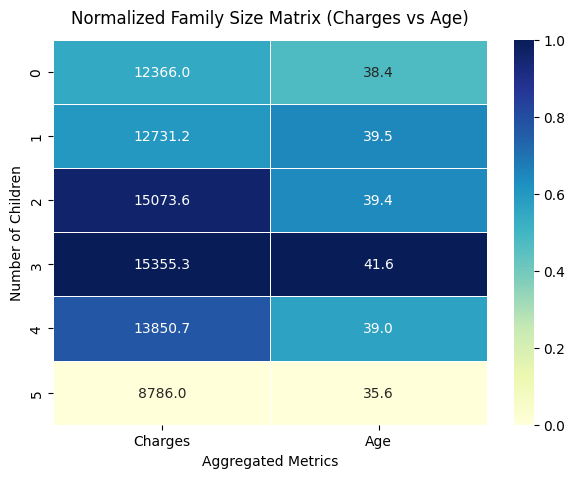

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Run your aggregation code
dependent_analysis = df.groupby('No_of_Children')[['Charges', 'Age']].mean()

# 2. Normalize the data between 0 and 1 for uniform color mapping
normalized_analysis = (dependent_analysis - dependent_analysis.min()) / (dependent_analysis.max() - dependent_analysis.min())

# 3. Plot the combined heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    normalized_analysis, 
    annot=dependent_analysis, # CRITICAL: Forces the heatmap to show original raw numbers, not the 0-1 decimals!
    fmt=".1f", 
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title('Normalized Family Size Matrix (Charges vs Age)', fontsize=12, pad=12)
plt.ylabel('Number of Children')
plt.xlabel('Aggregated Metrics')
plt.show()

In [62]:
df.to_excel("D:\Project_Beta\Cleaned_Data.xlsx",index=False)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ACER\AppData\Local\Temp\ipykernel_5724\2880371866.py:1: SyntaxWarning: invalid escape sequence '\P'
  df.to_excel("D:\Project_Beta\Cleaned_Data.xlsx",index=False)
